## Importación de paquetes
___
___

In [5]:
import os
import numpy as np                  # Importación de la biblioteca numpy para el manejo de arreglos
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import matplotlib.pyplot as plt     # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import seaborn as sns               # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
np.set_printoptions(
    suppress=True,
    linewidth=100,
    precision=2
)
plt.rcParams['figure.dpi'] = 120

## Funciones Auxiliares
___
___

### Categorización datos crudos

---
---

Esta función tiene como finalidad **transformar la representación de los valores contenidos en un conjunto de datos** mediante un proceso de conversión (*casting*) al tipo de dato de punto flotante. Esta transformación proporciona una representación homogénea de la información y facilita la identificación preliminar de la naturaleza de las variables que integran el conjunto de datos.

A partir del éxito o fracaso del proceso de conversión, es posible distinguir entre variables cuyos registros pueden interpretarse como valores numéricos y aquellas que presentan un comportamiento predominantemente categórico.

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: conjunto de datos que se desea analizar. Debe proporcionarse en un formato compatible con un arreglo de NumPy, donde cada columna represente una variable y cada fila una observación.

---

🔸 **Parámetros de salida**

La función genera los siguientes resultados:

- `datos_numericos`: conjunto de datos con la misma estructura que el conjunto de datos de entrada, cuyos registros han sido convertidos al tipo de dato float siempre que la  conversión sea posible. Los valores que no pueden convertirse se representan mediante np.nan.

- **Efecto en consola**: impresión del conjunto de datos resultante, utilizada como apoyo para verificar el resultado del proceso de conversión y facilitar una inspección preliminar de las variables.

---
---

In [6]:
def categorizacion_datos_crudos(datos):
    datos_numericos = []
    for i in datos:
        temporal = []
        for j in i:
            try:
                x = float(j)
            except:
                x = np.nan
            finally:
                temporal.append(x)
        datos_numericos.append(temporal)
    datos_numericos = np.array(datos_numericos)
    print(datos_numericos[:,:5])
    return datos_numericos

### Obtención de Porcentaje de Valores Nulos en un Conjunto de Datos

---
---

Esta función calcula el porcentaje de valores faltantes asociado a cada variable de un conjunto de datos. Este indicador constituye una de las métricas más utilizadas para evaluar la calidad e integridad de los datos durante las etapas de exploración y preprocesamiento.

La información obtenida facilita la identificación de variables con una alta proporción de registros ausentes y proporciona criterios objetivos para la aplicación de estrategias de imputación, eliminación o transformación de datos antes de realizar análisis posteriores.

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: conjunto de datos a analizar. Debe proporcionarse en un formato compatible con un arreglo de NumPy, donde cada columna representa una variable y cada fila una observación.

---

🔸 **Parámetros de salida**

La función genera los siguientes resultados:

- `categoria_pandas`: DataFrame de pandas que contiene el porcentaje de valores faltantes por cada variable del conjunto de datos.

- `categoria_pandas_ordenado`: DataFrame de pandas que contiene la misma información, ordenada de forma descendente según el porcentaje de valores faltantes.

- **Efecto en consola**: impresión del DataFrame sin ordenar, con las variables analizadas y su correspondiente porcentaje de valores faltantes.

---
---

In [105]:
def proporcion_datos_nulos_numpy(datos, etiquetas):
    porcentaje_datos_nulos = []
    for columna in datos:
        porcentaje_datos_nulos.append(
            pd.isna(columna).sum() / len(columna) * 100
        )
    categoria_pandas = pd.DataFrame({
        'Categoria': etiquetas,
        'Porcentaje': porcentaje_datos_nulos
    })
    categoria_pandas_ordenado = categoria_pandas.sort_values(
        by='Porcentaje',
        ascending=False
    )
    print(categoria_pandas.head())
    return (categoria_pandas, categoria_pandas_ordenado)

---
---

Esta función calcula el porcentaje de valores faltantes asociado a cada variable de un conjunto de datos. Este indicador constituye una de las métricas más utilizadas para evaluar la calidad e integridad de los datos durante las etapas de exploración y preprocesamiento.

La información obtenida facilita la identificación de variables con una alta proporción de registros ausentes y proporciona criterios objetivos para la aplicación de estrategias de imputación, eliminación o transformación de datos antes de realizar análisis posteriores.

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: conjunto de datos a analizar. Debe proporcionarse en un formato compatible con un DataFrame de Pandas, donde cada columna representa una variable y cada fila una observación.

---

🔸 **Parámetros de salida**

La función genera los siguientes resultados:

- `categoria_pandas`: DataFrame de pandas que contiene el porcentaje de valores faltantes por cada variable del conjunto de datos.

- `categoria_pandas_ordenado`: DataFrame de pandas que contiene la misma información, ordenada de forma descendente según el porcentaje de valores faltantes.

- **Efecto en consola**: impresión del DataFrame sin ordenar, con las variables analizadas y su correspondiente porcentaje de valores faltantes.

---
---

In [122]:
def completitud_variables_datos(datos, etiquetas):
    
    categoria_pandas = pd.DataFrame({'Categoria': etiquetas, 'Porcentaje': datos[etiquetas].isna().mean() * 100}).reset_index(drop=True)

    categoria_pandas_ordenado = categoria_pandas.sort_values(by='Porcentaje', ascending=False).reset_index(drop=True)

    print(categoria_pandas)

    return categoria_pandas, categoria_pandas_ordenado

In [141]:
def completitud_registros_datos(datos):

    distribucion_nulos = (datos.isna().sum(axis=1).value_counts().sort_index().reset_index())

    distribucion_nulos['count'] = (distribucion_nulos['count'] / len(datos) * 100)

    distribucion_nulos = distribucion_nulos.rename(columns={
            'index': 'Cantidad',
            'count': 'Porcentaje'
        }
    )

    distribucion_nulos_ordenados = (distribucion_nulos.sort_values(by='Porcentaje', ascending=False).reset_index(drop=True))

    return (distribucion_nulos, distribucion_nulos_ordenados)

### Clasificacion de Variables

---
---

Esta función tiene como finalidad clasificar las variables de un conjunto de datos en dos categorías: **variables numéricas** y **variables no numéricas**. La clasificación se realiza a partir del porcentaje de valores no convertibles obtenido tras aplicar un proceso de conversión (*casting*) de los registros al tipo de dato de punto flotante.

Como criterio general, una variable se clasifica como **no numérica** cuando la totalidad de sus registros no puede convertirse a un **valor numérico**. No obstante, la función permite definir un conjunto de excepciones para aquellos casos en los que una variable está representada mediante **valores numéricos**, pero su naturaleza corresponde a una categoría, etiqueta o identificador. Estas excepciones se establecen de acuerdo con el criterio del analista y prevalecen sobre la regla general de clasificación.

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `porcentajes`: lista que contiene el porcentaje de valores no convertibles a tipo numérico asociado a cada variable del conjunto de datos.

- `etiquetas`: lista con los nombres de las variables que conforman el conjunto de datos.

- `excepciones` *(opcional)*: lista con los nombres de las variables que deben excluirse del criterio general de clasificación. Si no se proporciona, la función asume una lista vacía.

---

🔸 **Parámetros de salida**

La función genera los siguientes resultados:

- `indice_numericos`: lista de enteros que representa las posiciones de las variables clasificadas como numéricas.

- `indice_no_numericos`: lista de enteros que representa las posiciones de las variables clasificadas como no numéricas (categóricas o identificadores).

- **Efecto en consola**: impresión de ambas listas resultantes como apoyo para la validación del procedimiento.

---
---

In [40]:
def clasificacion_variables(porcentajes, etiquetas, excepciones=None):
    if excepciones is None:
        excepciones = []
    indice_numericos, indice_no_numericos = [], []
    for i in range(len(porcentajes)):
        if (etiquetas[i] not in excepciones) and (porcentajes[i] != 100):
            indice_numericos.append(i)
        else:
            indice_no_numericos.append(i)
    print(f'Lista de índices correspondientes a variables numéricas: {indice_numericos}')
    print(f'Lista de índices correspondientes a variables categóricas: {indice_no_numericos}')
    return (indice_numericos, indice_no_numericos)

### Extracción de Columnas por Categorías

---
---

Esta función tiene como finalidad obtener las columnas del conjunto de datos asociadas a los índices proporcionados. Como resultado, genera una lista con las etiquetas correspondientes a las variables seleccionadas, preservando el orden indicado por los índices de entrada.

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `indice`: lista de enteros que contiene los índices de las columnas que se desean seleccionar.

- `etiquetas`: lista con las etiquetas que identifican las variables del conjunto de datos.

- `categoria`: cadena de caracteres utilizada para identificar o describir el conjunto de variables durante la presentación de los resultados en consola.

---

🔸 **Parámetros de salida**

La función genera los siguientes resultados:

- `columnas`: lista con las etiquetas correspondientes a las columnas seleccionadas.

- **Efecto en consola**: impresión de la lista de etiquetas obtenida.

---
---

In [9]:
def extraccion_columnas(indices, etiquetas, categoria):
    print(categoria)
    columnas = []
    for i in indices:
        columnas.append(etiquetas[i])
        print(etiquetas[i])
    return columnas

### Generación de Gráfico de Barra

---
---

Función utilizada para la **generación de gráficos de barras**. 

---

🔹 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `data_pandas`: conjunto de datos a representar gráficamente, almacenado en una estructura de tipo DataFrame de la librería pandas.

- `cols`: arreglo que contiene los nombres de las columnas que se desean graficar, definidos exactamente como aparecen en el DataFrame.

- `titulo`: cadena de caracteres utilizada para establecer el título del gráfico.

- `xlabel`: cadena de caracteres empleada para identificar la variable representada en el eje x.

- `ylabel`: cadena de caracteres empleada para identificar la variable representada en el eje y.

---

In [10]:
def generacion_grafico_barra(datos, columnas, titulo, xlabel, ylabel, ancho=7, alto=5):
    
    sns.set_theme(
        style="ticks",
        context="notebook",
        font_scale=1.0
    )

    # Dimensiones
    FIG_WIDTH = ancho
    FIG_HEIGHT = alto

    # Selección de columnas
    df = datos.loc[:, columnas]

    # Figura
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        dpi=120
    )

    # Gráfico
    sns.barplot(
        data=df,
        x=columnas[0],
        y=columnas[1],
        palette='tab10',
        ax=ax,
        color='black'
    )

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Etiquetas
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación de etiquetas
    ax.tick_params(axis='x', rotation=75)

    # Valores sobre barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    # Cuadrícula elegante
    ax.grid(axis='y', linestyle='-', alpha=0.8)

    # Bordes limpios
    sns.despine()

    plt.tight_layout()
    plt.show()

## Importación de los Datos
___
___

Durante esta etapa se llevan a cabo las siguientes actividades:

- Establecimiento de la ruta en la cual se encuentra ubicado el archivo fuente con la base de datos a procesar.

- Extracción de la información contenida en las bases de datos proporcionadas en formato numpy.array.

- Segmentación de la información proveída en etiquetas y datos.

### **Obtención de la Ruta del Notebook**

In [78]:
os.getcwd()

'c:\\Users\\ernesto.molina\\OneDrive - FUNKEN\\Documentos\\FKTrabajo\\Internos\\Curso Data Analyst\\S28 - A Loan Data Example with NumPy'

In [79]:
nombre_archivo_datos = 'loan-data.csv'     # Nombre del archivo que contiene los datos a procesar

### **Extracción de los Datos Proporcionados**

---
---

La carga de la información se realiza considerando todos los registros como cadenas de texto. La carga se realiza de esta manera para evitar la ocurrencia de errores durante el proceso de lectura y almacenamiento de los datos. 

Se emplea el punto y coma (`;`) como delimitador para separar los distintos campos contenidos en el conjunto de datos. La selección de este delimitador se definió a partir de analizar el formato de los datos crudos proporcionados.

---
---

In [80]:
datos_crudos_pd = pd.read_csv(nombre_archivo_datos, sep=';', encoding='latin1')

In [81]:
datos_crudos_np = np.loadtxt(nombre_archivo_datos, delimiter=';', dtype='str')     # Carga de los datos proporcionados en formato de cadena de caracteres para realizar, a posteriori, la clasificación de su formato
datos_crudos_np = datos_crudos_np.transpose()                                      # Conversión de columnas a filas para un mejor procesamiento de los datos para su clasificación y casteo
etiquetas = datos_crudos_np[:,0]                                                   # Extracción de las etiquetas (primera fila de la base de datos)
datos = datos_crudos_np[:,1:]                                                      # Extracción de los datos (filas restantes de la base de datos a partir de la segunda)
print(etiquetas)
print(datos[:,:5])

['id' 'issue_d' 'loan_amnt' 'loan_status' 'funded_amnt' 'term' 'int_rate' 'installment' 'grade'
 'sub_grade' 'verification_status' 'url' 'addr_state' 'total_pymnt']
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222

---
---

Como resultado del proceso de carga y extracción de información, se generan las siguientes estructuras de datos:

- `etiquetas`: arreglo que contiene los nombres de las variables o características presentes en el conjunto de datos original. Del análisis de los datos crudos proporcionados se identifica que estas etiquetas se encuentran registradas en la primera fila de la base de datos. Su función es describir cada atributo y facilitar la identificación e interpretación de la información almacenada.

- `datos`: estructura que almacena los valores correspondientes a cada uno de los registros del conjunto de datos, manteniendo la asociación entre los datos y las etiquetas que los describen. Esta información está compuesta por todas las filas comprendidas entre la segunda y la última fila de la base de datos proporcionada.

---
---

## Análisis Exploratorio de los Datos
___
___

### 🤖 **Exploración del Formato de los Datos Extraídos (variables numéricas y variables no numéricos)**

---
---

Una vez cargados los registros, se realiza un proceso automático de formateo de los datos con el objetivo de convertir cada elemento a un valor numérico de tipo punto flotante. 

Cuando un registro no puede convertirse debido a 

- incompatibilidades en su formato 

- presencia de valores faltantes

Se le asigna el valor especial `np.nan`, el cual permite identificar y gestionar posteriormente los datos no válidos o ausentes durante el análisis.

---
---

In [82]:
datos_numericos = categorizacion_datos_crudos(datos=datos)

[[48010226.   57693261.   59432726.   53222800.   57803010.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [      13.33         nan         nan         nan       19.19]
 [    1184.86      938.57      494.86      300.35      296.78]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [    9452.96     4679.7      1969.83     1793.68     1178.51]]


---
---

Como resultado de este proceso se obtienen la siguiente variable:

- `datos_numericos`: conjunto de datos cuyos elementos han sido convertidos a valores numéricos de tipo punto flotante. Aquellos registros que no pudieron ser transformados debido a incompatibilidades en su formato se representan mediante el valor especial `np.nan`.

---
---

### 🤖 **Exploración de Métricas relacionadas al Proceso de Normalización de Formato de Datos**

In [83]:
categoria_pandas, ordenado_pandas = proporcion_datos_nulos_numpy(datos=datos_numericos, etiquetas=etiquetas)

     Categoria  Porcentaje
0           id         0.0
1      issue_d       100.0
2    loan_amnt         5.0
3  loan_status       100.0
4  funded_amnt         5.0


### 🧠 **Análisis Gráfico del Proceso de Categorización e Integridad de Datos Numéricos**

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_28812\3775951217.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


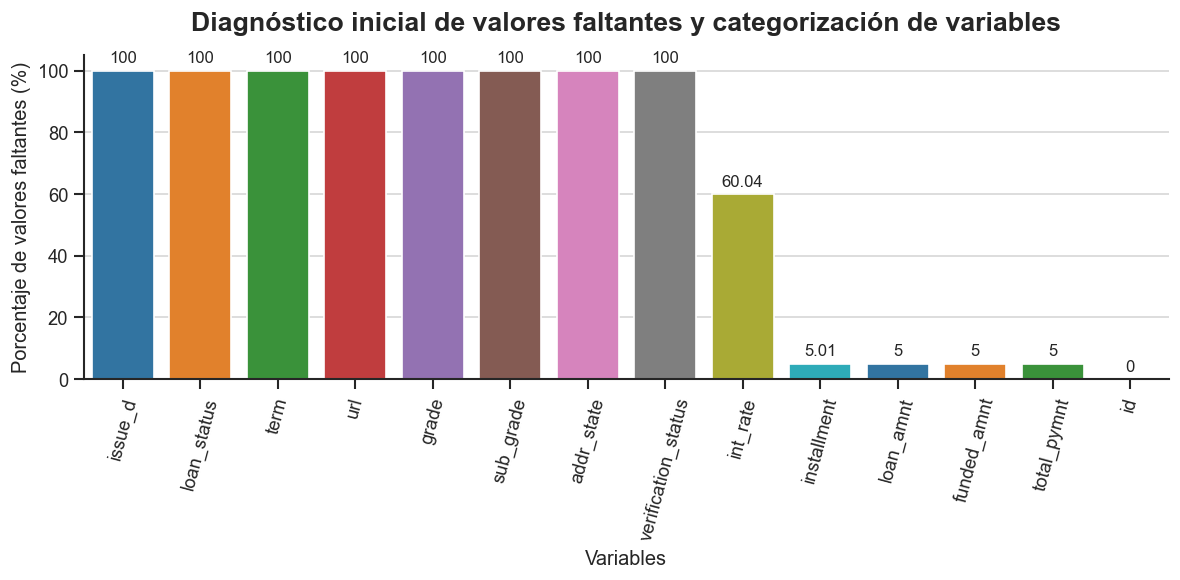

In [84]:
generacion_grafico_barra(
    datos=ordenado_pandas,
    columnas=ordenado_pandas.columns,
    titulo='Diagnóstico inicial de valores faltantes y categorización de variables',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

---
---

A partir de los resultados obtenidos, se pueden establecer las siguientes conclusiones:

- Las variables `issue_d`, `loan_status`, `term`, `url`, `grade`, `sub_grade`, `addr_state` y `verification_status` no pueden convertirse directamente a un tipo de dato numérico, por lo que se clasifican preliminarmente como variables categóricas. Debido a la naturaleza de estas variables, el procedimiento empleado no permite evaluar, en esta etapa, la calidad o integridad de los datos asociados a sus registros.

- Aunque la variable `id` está compuesta por valores numéricos, su función es identificar de manera única cada registro del conjunto de datos. En consecuencia, se considera una variable categórica de identificación y no una variable numérica de análisis. Por esta razón, el porcentaje de valores no convertibles no constituye un criterio adecuado para evaluar la calidad de la información contenida en esta variable.

- Las variables `int_rate`, `loan_amnt`, `funded_amnt`, `installment` y `total_pymnt` presentan valores numéricos junto con diferentes proporciones de valores faltantes. Dado que la mayoría de sus registros corresponden a datos numéricos y que los valores no convertibles se asocian principalmente a registros ausentes, estas variables se clasifican como variables numéricas. No obstante, la presencia de valores faltantes evidencia diferencias en el nivel de integridad de la información disponible para cada una de ellas.

    En particular, se obtienen las siguientes métricas:

    * La variable `int_rate` presenta un **60.04 %** de valores faltantes, siendo la variable numérica con el mayor grado de pérdida de información.
    * La variable `installment` presenta un **5.01 %** de valores faltantes.
    * Las variables numéricas restantes presentan aproximadamente un **5 %** de valores faltantes, lo que indica un nivel de integridad significativamente superior al observado en `int_rate`.

---
---

In [85]:
lista_excepciones = ['id']

### 🤖 **Clasificación de las Agrupaciones de Datos**

---
---

Se realiza un análisis de las variables que componen el conjunto de datos con el propósito de identificar aquellas cuyos registros pueden convertirse a un tipo de dato numérico. Para ello, se evalúa el porcentaje de valores faltantes y de valores no convertibles obtenido en la etapa anterior, considerando además aquellas variables que, por su naturaleza, constituyen excepciones al criterio de clasificación.

A partir de este procedimiento se establecen los siguientes criterios:

* Si el porcentaje de valores no convertibles es igual al **100 %**, se concluye que ninguno de los registros de la variable puede interpretarse como un valor numérico. En consecuencia, la variable se clasifica preliminarmente como de naturaleza categórica.
* Las variables identificadas como excepciones no se clasifican utilizando el criterio anterior. Aunque sus registros estén representados mediante valores numéricos, su función dentro del conjunto de datos corresponde a categorías, etiquetas o identificadores, por lo que se consideran variables categóricas.

Es importante destacar que la capacidad de una variable para representarse mediante valores numéricos no implica necesariamente que esta sea una variable cuantitativa. En numerosos conjuntos de datos, las categorías, etiquetas o identificadores se codifican mediante números que carecen de significado numérico desde el punto de vista analítico.

Por esta razón, la clasificación definitiva de una variable no debe basarse únicamente en el formato de los datos que contiene, sino también en el propósito que desempeña dentro del conjunto de datos y en la naturaleza de la información que representa.

---
---

In [86]:
indice_numericos, indice_categoricos = clasificacion_variables(porcentajes=list(categoria_pandas['Porcentaje']), etiquetas=etiquetas, excepciones=lista_excepciones)

Lista de índices correspondientes a variables numéricas: [2, 4, 6, 7, 13]
Lista de índices correspondientes a variables categóricas: [0, 1, 3, 5, 8, 9, 10, 11, 12]


#### **Verificación del Proceso de Recategorización**

In [87]:
columnas_no_numericas, columnas_numericas = [], []

In [88]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
id
issue_d
loan_status
term
grade
sub_grade
verification_status
url
addr_state


In [89]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
loan_amnt
funded_amnt
int_rate
installment
total_pymnt


### 🧠 **Cambio de Nombre de las Etiquetas**

___
___

Este procedimiento se realiza para proveerle una identificación más intuitiva a cada una de las variables contenidas en la base de datos
___
___

In [90]:
dic_etiquetas = {
    'id' : 'identificador',
    'issue_d' : 'fecha_prestamo',
    'loan_status' : 'estado_prestamo',
    'loan_amnt' : 'solicitud_prestamo_EUR',
    'funded_amnt' : 'aceptacion_prestamo_EUR',
    'term' : 'meses_prestamo',
    'grade' : 'grado',
    'sub_grade' : 'sub_grado',
    'verification_status' : 'estado_verificacion',
    'int_rate' : 'razon_intereses',
    'installment' : 'pago_mensual_EUR',
    'total_pymnt' : 'pago_efectuado_EUR',
    'url' : 'enlace',
    'addr_state' : 'estado',
}

In [91]:
etiquetas_previas = etiquetas.copy()
etiquetas = []

In [92]:
for i in etiquetas_previas:
    try:
        etiquetas.append(dic_etiquetas[i])
    except:
        pass

#### **Verificación del Proceso de Renombramiento de Variables**

In [93]:
columnas_no_numericas, columnas_numericas = [], []

In [94]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
identificador
fecha_prestamo
estado_prestamo
meses_prestamo
grado
sub_grado
estado_verificacion
enlace
estado


In [95]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
solicitud_prestamo_EUR
aceptacion_prestamo_EUR
razon_intereses
pago_mensual_EUR
pago_efectuado_EUR


### 🤖 **Creación del DataFrame con Datos Crudos**

In [96]:
datos_pandas = pd.DataFrame(datos.transpose(), columns=etiquetas)
datos_pandas.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   identificador            10000 non-null  str  
 1   fecha_prestamo           10000 non-null  str  
 2   solicitud_prestamo_EUR   10000 non-null  str  
 3   estado_prestamo          10000 non-null  str  
 4   aceptacion_prestamo_EUR  10000 non-null  str  
 5   meses_prestamo           10000 non-null  str  
 6   razon_intereses          10000 non-null  str  
 7   pago_mensual_EUR         10000 non-null  str  
 8   grado                    10000 non-null  str  
 9   sub_grado                10000 non-null  str  
 10  estado_verificacion      10000 non-null  str  
 11  enlace                   10000 non-null  str  
 12  estado                   10000 non-null  str  
 13  pago_efectuado_EUR       10000 non-null  str  
dtypes: str(14)
memory usage: 1.1 MB


### 🤖 **Casteo de los Datos en el DataFrame**

#### *Variables Numéricas*

In [97]:
datos_pandas[columnas_numericas] = datos_pandas[columnas_numericas].apply(pd.to_numeric, errors = 'coerce')

In [98]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           10000 non-null  str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          10000 non-null  str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           10000 non-null  str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    10000 non-null  str    
 9   sub_grado                10000 non-null  str    
 10  estado_verificacion      10000 non-null  str    
 11  enlace                   10000 non-null  str    
 12  estado                   10000 non-null  str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

#### *Variables No Numéricas*

In [99]:
datos_pandas[columnas_no_numericas] = datos_pandas[columnas_no_numericas].replace('', np.nan)

In [100]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           9500 non-null   str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          9500 non-null   str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           9500 non-null   str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    9485 non-null   str    
 9   sub_grado                9486 non-null   str    
 10  estado_verificacion      9500 non-null   str    
 11  enlace                   10000 non-null  str    
 12  estado                   9500 non-null   str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

### 🤖 **Exploración de la Integridad de la Base de Datos**

####  **Métricas de Completitud de Datos**

#####  *Completitud por variable*

___
___

Una vez obtenida la estructura de datos resultante de las etapas anteriores, se dispone de un conjunto de datos consistente respecto al formato de las variables y a la identificación de los valores presentes y faltantes. Esta estructura permite realizar un análisis de la integridad de los datos en términos de su completitud, aplicando una metodología equivalente a la utilizada en la etapa inicial del proceso de limpieza para cuantificar la presencia de valores faltantes tanto por variables de la base de datos como por los registros proporcionados.

___
___

In [123]:
completitud_variables_pandas, completitud_variables_ordenado = completitud_variables_datos(datos=datos_pandas, etiquetas=etiquetas)

                  Categoria  Porcentaje
0             identificador        0.00
1            fecha_prestamo        5.00
2    solicitud_prestamo_EUR        5.00
3           estado_prestamo        5.00
4   aceptacion_prestamo_EUR        5.00
5            meses_prestamo        5.00
6           razon_intereses       60.04
7          pago_mensual_EUR        5.01
8                     grado        5.15
9                 sub_grado        5.14
10      estado_verificacion        5.00
11                   enlace        0.00
12                   estado        5.00
13       pago_efectuado_EUR        5.00


#####  *Completitud por registro*

In [142]:
completitud_registros_pandas, completitud_registros_ordenado = completitud_registros_datos(datos=datos_pandas)

### 🧠 **Análisis Gráfico de la Integridad de los Datos Proporcionados**

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_28812\3775951217.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


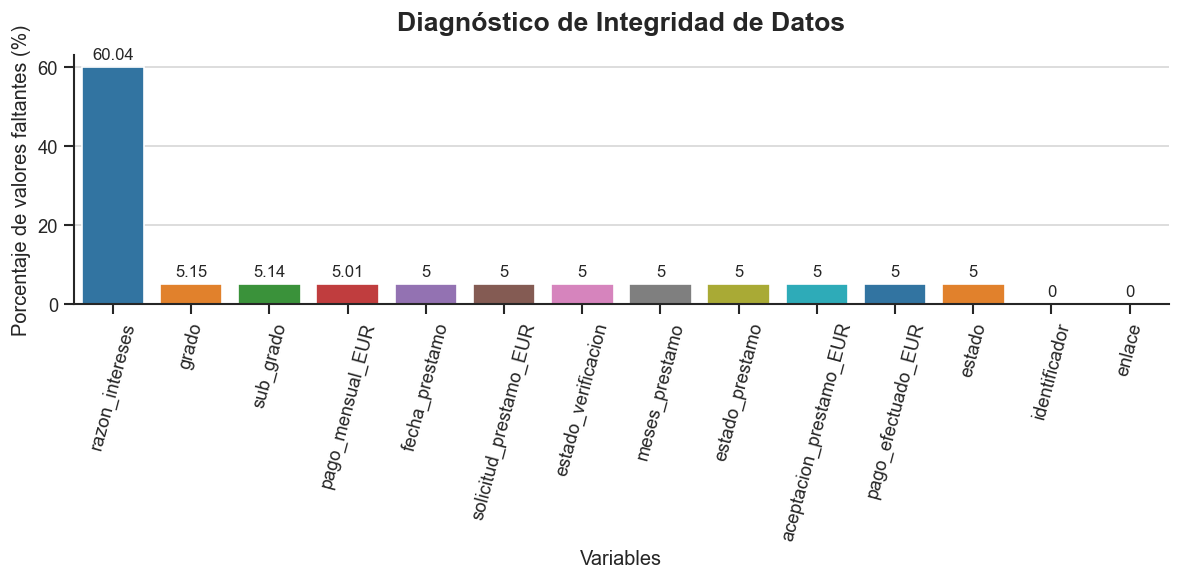

In [ ]:
generacion_grafico_barra(
    datos=completitud_variables_ordenado,
    columnas=completitud_variables_ordenado.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Variables)',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

---
---

A partir de los resultados obtenidos, se establecen las siguientes conclusiones:

- La variable `razon_interes` presenta el mayor porcentaje de valores faltantes del conjunto de datos. En consecuencia, si no es posible aplicar una estrategia de imputación adecuada, la información disponible para esta variable resulta limitada para realizar análisis posteriores, ya que el **60.04 %** de sus registros se encuentra ausente.

- Las variables `identificador` y `enlace` presentan un **100 %** de completitud, por lo que no requieren la aplicación de procedimientos de imputación relacionados con la presencia de valores faltantes.

- Las demás variables presentan bajos porcentajes de valores faltantes **(~5 %)**. No obstante, su nivel de integridad puede mejorarse mediante la aplicación de técnicas de imputación, siempre que estas se encuentren debidamente justificadas y fundamentadas en la relación existente entre las variables del conjunto de datos.

---
---

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_28812\3775951217.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


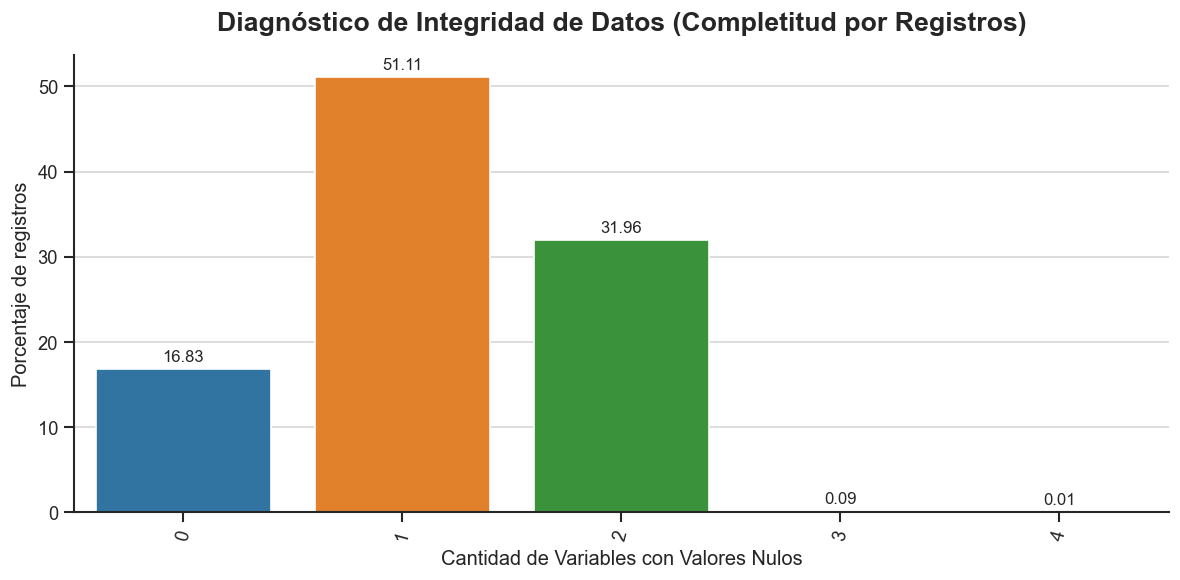

In [143]:
generacion_grafico_barra(
    datos=completitud_registros_ordenado,
    columnas=completitud_registros_ordenado.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Registros)',
    xlabel='Cantidad de Variables con Valores Nulos',
    ylabel='Porcentaje de registros',
    ancho=10
)

In [33]:
datos_pandas.head()

,identificador,fecha_prestamo,solicitud_prestamo_EUR,estado_prestamo,aceptacion_prestamo_EUR,meses_prestamo,razon_intereses,pago_mensual_EUR,grado,sub_grado,estado_verificacion,enlace,estado,pago_efectuado_EUR
0,48010226,May-15,35000.0,Current,35000.0,36 months,13.33,1184.86,C,C3,Verified,https://www.lendingclub.com/browse/loanDetail....,CA,9452.96
1,57693261,NaN,30000.0,Current,30000.0,36 months,NaN,938.57,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,NY,4679.70
2,59432726,Sep-15,15000.0,Current,15000.0,36 months,NaN,494.86,B,B5,Verified,https://www.lendingclub.com/browse/loanDetail....,PA,1969.83
3,53222800,Jul-15,9600.0,Current,9600.0,36 months,NaN,300.35,A,A5,Not Verified,https://www.lendingclub.com/browse/loanDetail....,OH,1793.68
4,57803010,Aug-15,8075.0,Current,8075.0,36 months,19.19,296.78,NaN,E3,Source Verified,https://www.lendingclub.com/browse/loanDetail....,TX,1178.51


___
___



### **Observaciones por Variables**

Existen diversas relaciones que pueden establecerse entre los valores contenidos en las variables que conforman la base de datos proporcionada:

* Se analiza la posible correlación entre las variables `loan_amnt` y `funded_amnt`, con el objetivo de evaluar la viabilidad de un proceso de imputación de valores ausentes en ambas columnas, en caso de existir una relación estadísticamente significativa entre ellas.

* Se identifica una relación directa entre la codificación de las variables `sub_grade` y `grade`, lo que permite considerar la posibilidad de realizar procesos de imputación cruzada en aquellos casos en los que se presenten valores faltantes en alguna de estas variables, aprovechando su correspondencia estructural.

### 🤖 **Generación del Primer CheckPoint en Formato CSV**

In [26]:
datos_pandas.to_csv('checkpoint_01.csv')